<style>
.rendered_html h1 { color: #1f4e79; }
.rendered_html h2 { color: #0f766e; }
.rendered_html h3, .rendered_html h4 { color: #7c3aed; }
</style>

# Optimizer Comparison for Implicit Matrix Factorization

This notebook compares stochastic optimizers using the same implicit Matrix Factorization model, data split, negative samples, and evaluation metrics.

## Setup

We load libraries, set project paths, and prepare output folders.

In [1]:
from pathlib import Path
import math
import pickle
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
figures_dir = project_root / "results" / "figures"
tables_dir = project_root / "results" / "tables"

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

## Load Processed Data

We use the processed files from notebook 01 so every optimizer sees the same train/test split.

In [2]:
train_data = pd.read_csv(processed_dir / "train_data.csv")
test_data = pd.read_csv(processed_dir / "test_data.csv")
movies = pd.read_csv(processed_dir / "movies_processed.csv")

with open(processed_dir / "metadata.pkl", "rb") as file:
    metadata = pickle.load(file)

num_users = metadata["num_users"]
num_movies = metadata["num_movies"]

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)
print("Movies:", movies.shape)
print("Users:", num_users)
print("Movies:", num_movies)

Train data: (54433, 7)
Test data: (942, 7)
Movies: (1682, 25)
Users: 943
Movies: 1682


## Reproducibility and GPU

We use fixed random seeds and GPU support. If CUDA is unavailable, PyTorch falls back to CPU.

In [3]:
seed = 42

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seeds(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Fair Comparison Rules

All optimizers must use the same data, same model, same negative samples, same number of epochs, and same evaluation metrics. Only the optimizer changes. This makes the comparison fair.

The main comparison includes SGD, SGD with Momentum, Adam, Adagrad, RMSprop, and FTRL when the external FTRL package is available.


## FTRL Availability

FTRL is included as an additional optimizer using the external `pytorch-optimizer` package because it is not available as a standard `torch.optim` optimizer.

Installation command:

```bash
pip install pytorch-optimizer
```

Because FTRL comes from an external package, its implementation source is different from `torch.optim` optimizers, but it is still compared using the same model, data, and metrics.


In [4]:
try:
    from pytorch_optimizer import FTRL
    FTRL_AVAILABLE = True
except ImportError:
    FTRL_AVAILABLE = False
    print("FTRL is not available. Install it with: pip install pytorch-optimizer")


In [5]:
embedding_dim = 32
batch_size = 512
num_epochs = 30
K = 10

optimizer_learning_rates = {
    "SGD": 0.05,
    "Momentum": 0.05,
    "Adam": 0.001,
    "Adagrad": 0.01,
    "RMSprop": 0.001,
}

if FTRL_AVAILABLE:
    optimizer_learning_rates["FTRL"] = 0.01
else:
    print("Skipping FTRL in the main comparison because pytorch-optimizer is not installed.")

optimizer_learning_rates


{'SGD': 0.05,
 'Momentum': 0.05,
 'Adam': 0.001,
 'Adagrad': 0.01,
 'RMSprop': 0.001,
 'FTRL': 0.01}

## Negative Sampling

Implicit data gives positive interactions only. We add one negative movie for each positive training interaction so BCE loss has both `1` and `0` labels.

Negatives are sampled from movies that are absent from both the train split and the held-out test split for that user. This avoids accidentally treating a user's test movie as a negative example during training.


In [6]:
def create_train_with_negatives(train_data, test_data, num_movies, seed):
    all_movie_indices = set(range(num_movies))
    all_positive_data = pd.concat([train_data, test_data], ignore_index=True)
    user_positive_movies = all_positive_data.groupby("user_idx")["movie_idx"].apply(set).to_dict()

    rng = np.random.default_rng(seed)
    negative_rows = []

    for row in train_data.itertuples(index=False):
        seen_movies = user_positive_movies[row.user_idx]
        candidate_movies = list(all_movie_indices - seen_movies)
        negative_movie_idx = int(rng.choice(candidate_movies))
        negative_movie_id = metadata["idx_to_movie"][negative_movie_idx]

        negative_rows.append({
            "user_id": row.user_id,
            "movie_id": negative_movie_id,
            "interaction": 0,
            "timestamp": row.timestamp,
            "user_idx": row.user_idx,
            "movie_idx": negative_movie_idx,
        })

    positive_samples = train_data[["user_id", "movie_id", "interaction", "timestamp", "user_idx", "movie_idx"]].copy()
    negative_samples = pd.DataFrame(negative_rows)

    return (
        pd.concat([positive_samples, negative_samples], ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


train_with_negatives = create_train_with_negatives(train_data, test_data, num_movies, seed)

display(train_with_negatives["interaction"].value_counts().sort_index())


interaction
0    54433
1    54433
Name: count, dtype: int64

## DataLoader

The same mini-batches are used for every optimizer.

In [7]:
train_dataset = TensorDataset(
    torch.tensor(train_with_negatives["user_idx"].values, dtype=torch.long),
    torch.tensor(train_with_negatives["movie_idx"].values, dtype=torch.long),
    torch.tensor(train_with_negatives["interaction"].values, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Training samples:", len(train_dataset))
print("Batches per epoch:", len(train_loader))

Training samples: 108866
Batches per epoch: 213


## Model

Every optimizer trains a fresh copy of the same Implicit Matrix Factorization model.

In [8]:
class ImplicitMatrixFactorization(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=32, use_bias=True):
        super().__init__()
        self.user_embeddings = nn.Embedding(num_users, embedding_dim)
        self.movie_embeddings = nn.Embedding(num_movies, embedding_dim)
        self.use_bias = use_bias

        if use_bias:
            self.user_bias = nn.Embedding(num_users, 1)
            self.movie_bias = nn.Embedding(num_movies, 1)

        nn.init.normal_(self.user_embeddings.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.movie_embeddings.weight, mean=0.0, std=0.01)

        if use_bias:
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        user_vector = self.user_embeddings(user_idx)
        movie_vector = self.movie_embeddings(movie_idx)
        score = (user_vector * movie_vector).sum(dim=1)

        if self.use_bias:
            score = score + self.user_bias(user_idx).squeeze(1)
            score = score + self.movie_bias(movie_idx).squeeze(1)

        return score


def create_optimizer(optimizer_name, model, lr):
    if optimizer_name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr)
    if optimizer_name == "Momentum":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if optimizer_name == "Adagrad":
        return torch.optim.Adagrad(model.parameters(), lr=lr)
    if optimizer_name == "RMSprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr)
    if optimizer_name == "FTRL":
        if not FTRL_AVAILABLE:
            raise ImportError("FTRL is not available. Install it with: pip install pytorch-optimizer")
        return FTRL(model.parameters(), lr=lr, beta=1.0)

    raise ValueError(f"Unknown optimizer: {optimizer_name}")


## Evaluation Functions

We reuse the same Top-K idea from notebook 03: score all movies, remove seen movies, and check whether the held-out test movie appears in the Top-10.

In [9]:
def synchronize_cuda():
    if device.type == "cuda":
        torch.cuda.synchronize()


def get_peak_memory_mb():
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated() / (1024 ** 2)

    return None


seen_movies_by_user = train_data.groupby("user_idx")["movie_idx"].apply(set).to_dict()
all_movie_indices = torch.arange(num_movies, dtype=torch.long, device=device)


def recommend_top_k(model, user_idx, k=10):
    model.eval()

    with torch.no_grad():
        user_tensor = torch.full((num_movies,), int(user_idx), dtype=torch.long, device=device)
        scores = model(user_tensor, all_movie_indices).detach().cpu().numpy()

    seen_movies = seen_movies_by_user.get(user_idx, set())
    if seen_movies:
        scores[list(seen_movies)] = -np.inf

    return np.argsort(scores)[-k:][::-1].tolist()


def hit_rate_at_k(recommended_items, test_item):
    return int(test_item in recommended_items)


def precision_at_k(recommended_items, test_item, k=10):
    return hit_rate_at_k(recommended_items, test_item) / k


def recall_at_k(recommended_items, test_item):
    return hit_rate_at_k(recommended_items, test_item)


def ndcg_at_k(recommended_items, test_item):
    if test_item not in recommended_items:
        return 0.0

    rank = recommended_items.index(test_item) + 1
    return 1 / math.log2(rank + 1)


def evaluate_model(model, test_subset, k=10):
    if len(test_subset) == 0:
        synchronize_cuda()
        return {"Precision@10": 0.0, "Recall@10": 0.0, "HitRate@10": 0.0, "NDCG@10": 0.0}

    precision_scores = []
    recall_scores = []
    hit_rate_scores = []
    ndcg_scores = []

    for row in test_subset.itertuples(index=False):
        recommendations = recommend_top_k(model, row.user_idx, k=k)
        test_movie_idx = int(row.movie_idx)

        precision_scores.append(precision_at_k(recommendations, test_movie_idx, k=k))
        recall_scores.append(recall_at_k(recommendations, test_movie_idx))
        hit_rate_scores.append(hit_rate_at_k(recommendations, test_movie_idx))
        ndcg_scores.append(ndcg_at_k(recommendations, test_movie_idx))

    synchronize_cuda()

    return {
        "Precision@10": float(np.mean(precision_scores)),
        "Recall@10": float(np.mean(recall_scores)),
        "HitRate@10": float(np.mean(hit_rate_scores)),
        "NDCG@10": float(np.mean(ndcg_scores)),
    }


## Training Function

Each optimizer starts from a fresh model with the same random seed. The function records loss, time, and memory usage.

In [10]:
def train_model(optimizer_name, learning_rate, num_epochs_to_train=num_epochs, optimizer_factory=None):
    set_seeds(seed)

    if device.type == "cuda":
        torch.cuda.empty_cache()

    model = ImplicitMatrixFactorization(
        num_users=num_users,
        num_movies=num_movies,
        embedding_dim=embedding_dim,
        use_bias=True,
    ).to(device)

    loss_function = nn.BCEWithLogitsLoss()
    if optimizer_factory is None:
        optimizer = create_optimizer(optimizer_name, model, learning_rate)
    else:
        optimizer = optimizer_factory(model, learning_rate)
    history = []

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    synchronize_cuda()
    training_start = time.perf_counter()

    for epoch in range(1, num_epochs_to_train + 1):
        model.train()
        synchronize_cuda()
        epoch_start = time.perf_counter()
        total_loss = 0.0
        total_examples = 0

        for batch_users, batch_movies, batch_labels in train_loader:
            batch_users = batch_users.to(device)
            batch_movies = batch_movies.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            scores = model(batch_users, batch_movies)
            loss = loss_function(scores, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(batch_labels)
            total_examples += len(batch_labels)

        synchronize_cuda()
        average_loss = total_loss / total_examples
        epoch_time = time.perf_counter() - epoch_start
        elapsed_time = time.perf_counter() - training_start
        memory_usage_mb = get_peak_memory_mb()

        history.append({
            "optimizer": optimizer_name,
            "epoch": epoch,
            "loss": average_loss,
            "epoch_time_seconds": epoch_time,
            "elapsed_time_seconds": elapsed_time,
            "memory_usage_mb": memory_usage_mb,
            "learning_rate": learning_rate,
        })

    synchronize_cuda()
    training_time = time.perf_counter() - training_start
    memory_usage_mb = get_peak_memory_mb()

    return model, pd.DataFrame(history), training_time, memory_usage_mb


## Sparse Data Subsets

Inactive users are users in the lowest 25% of training interaction counts. Unpopular movies are movies in the lowest 25% of item popularity.

We define these subsets before training so each optimizer is evaluated on the full test set, inactive-user test rows, and unpopular-item test rows inside the same loop.


In [11]:
user_interaction_counts = train_data.groupby("user_idx").size()
inactive_threshold = user_interaction_counts.quantile(0.25)
inactive_user_indices = set(user_interaction_counts[user_interaction_counts <= inactive_threshold].index)

item_popularity = train_data.groupby("movie_idx").size()
unpopular_threshold = item_popularity.quantile(0.25)
unpopular_movie_indices = set(item_popularity[item_popularity <= unpopular_threshold].index)

inactive_test_data = test_data[test_data["user_idx"].isin(inactive_user_indices)].copy()
unpopular_test_data = test_data[test_data["movie_idx"].isin(unpopular_movie_indices)].copy()

print("Inactive-user test rows:", len(inactive_test_data))
print("Unpopular-item test rows:", len(unpopular_test_data))


Inactive-user test rows: 239
Unpopular-item test rows: 25


## Train and Evaluate Optimizers

For each optimizer, we train the model, evaluate Top-10 recommendation quality, and save the model weights.

In [12]:
all_history = []
metrics_rows = []

for optimizer_name, lr in optimizer_learning_rates.items():
    print(f"Training {optimizer_name} with lr={lr}")

    model, history_df, training_time, memory_usage_mb = train_model(
        optimizer_name,
        lr,
        num_epochs_to_train=num_epochs,
    )

    metrics = evaluate_model(model, test_data, k=K)
    inactive_metrics = evaluate_model(model, inactive_test_data, k=K)
    unpopular_metrics = evaluate_model(model, unpopular_test_data, k=K)
    synchronize_cuda()
    memory_usage_mb = get_peak_memory_mb()

    model_file_name = f"mf_{optimizer_name.lower()}.pth"
    model_path = models_dir / model_file_name
    model_state_dict = {name: value.detach().cpu() for name, value in model.state_dict().items()}

    torch.save({
        "model_state_dict": model_state_dict,
        "optimizer": optimizer_name,
        "num_users": num_users,
        "num_movies": num_movies,
        "embedding_dim": embedding_dim,
        "learning_rate": lr,
        "num_epochs": num_epochs,
        "training_time_seconds": training_time,
    }, model_path)

    final_loss = history_df["loss"].iloc[-1]
    best_loss = history_df["loss"].min()

    all_history.append(history_df)

    metrics_rows.append({
        "optimizer": optimizer_name,
        "learning_rate": lr,
        "final_loss": final_loss,
        "best_loss": best_loss,
        "training_time_seconds": training_time,
        "memory_usage_mb": memory_usage_mb,
        **metrics,
        "inactive_users_count": len(inactive_test_data),
        "inactive_user_Precision@10": inactive_metrics["Precision@10"],
        "inactive_user_Recall@10": inactive_metrics["Recall@10"],
        "inactive_user_HitRate@10": inactive_metrics["HitRate@10"],
        "inactive_user_NDCG@10": inactive_metrics["NDCG@10"],
        "unpopular_items_count": len(unpopular_test_data),
        "unpopular_item_Precision@10": unpopular_metrics["Precision@10"],
        "unpopular_item_Recall@10": unpopular_metrics["Recall@10"],
        "unpopular_item_HitRate@10": unpopular_metrics["HitRate@10"],
        "unpopular_item_NDCG@10": unpopular_metrics["NDCG@10"],
    })

    print(metrics)

    model.to("cpu")
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

optimizer_history_df = pd.concat(all_history, ignore_index=True)
optimizer_metrics_df = pd.DataFrame(metrics_rows)

optimizer_history_df.to_csv(tables_dir / "optimizer_training_history.csv", index=False)
optimizer_metrics_df.to_csv(tables_dir / "optimizer_comparison_metrics.csv", index=False)

display(optimizer_metrics_df)


Training SGD with lr=0.05
{'Precision@10': 0.008067940552016985, 'Recall@10': 0.08067940552016985, 'HitRate@10': 0.08067940552016985, 'NDCG@10': 0.04056504934348608}
Training Momentum with lr=0.05
{'Precision@10': 0.008174097664543524, 'Recall@10': 0.08174097664543524, 'HitRate@10': 0.08174097664543524, 'NDCG@10': 0.040950714202833687}
Training Adam with lr=0.001
{'Precision@10': 0.009766454352441615, 'Recall@10': 0.09766454352441614, 'HitRate@10': 0.09766454352441614, 'NDCG@10': 0.04553182330984885}
Training Adagrad with lr=0.01
{'Precision@10': 0.008386411889596603, 'Recall@10': 0.08386411889596602, 'HitRate@10': 0.08386411889596602, 'NDCG@10': 0.04289471704498879}
Training RMSprop with lr=0.001
{'Precision@10': 0.009341825902335458, 'Recall@10': 0.09341825902335456, 'HitRate@10': 0.09341825902335456, 'NDCG@10': 0.044952039435840814}
Training FTRL with lr=0.01
{'Precision@10': 0.008280254777070064, 'Recall@10': 0.08280254777070063, 'HitRate@10': 0.08280254777070063, 'NDCG@10': 0.0411

,optimizer,learning_rate,final_loss,best_loss,training_time_seconds,memory_usage_mb,Precision@10,Recall@10,HitRate@10,NDCG@10,inactive_users_count,inactive_user_Precision@10,inactive_user_Recall@10,inactive_user_HitRate@10,inactive_user_NDCG@10,unpopular_items_count,unpopular_item_Precision@10,unpopular_item_Recall@10,unpopular_item_HitRate@10,unpopular_item_NDCG@10
0,SGD,0.050,0.660215,0.660215,48.787008,1.312988,0.008068,0.080679,0.080679,0.040565,239,0.009623,0.096234,0.096234,0.048442,25,0.0,0.0,0.0,0.0
1,Momentum,0.050,0.533848,0.533848,77.390044,1.312988,0.008174,0.081741,0.081741,0.040951,239,0.009623,0.096234,0.096234,0.048692,25,0.0,0.0,0.0,0.0
2,Adam,0.001,0.203005,0.203005,128.988508,1.683105,0.009766,0.097665,0.097665,0.045532,239,0.012971,0.129707,0.129707,0.058065,25,0.0,0.0,0.0,0.0
3,Adagrad,0.010,0.385888,0.385888,124.817251,1.683105,0.008386,0.083864,0.083864,0.042895,239,0.010460,0.104603,0.104603,0.050847,25,0.0,0.0,0.0,0.0
4,RMSprop,0.001,0.214925,0.214925,121.724965,1.351562,0.009342,0.093418,0.093418,0.044952,239,0.012971,0.129707,0.129707,0.058812,25,0.0,0.0,0.0,0.0
5,FTRL,0.010,0.686210,0.686210,143.048179,2.379395,0.008280,0.082803,0.082803,0.041178,239,0.010042,0.100418,0.100418,0.049591,25,0.0,0.0,0.0,0.0


## Convergence Analysis

We summarize final loss, best loss, the first stable epoch, and training time.

In [13]:
def stable_epoch(losses, tolerance=0.001, patience=3):
    losses = list(losses)

    for index in range(patience, len(losses)):
        recent_changes = [abs(losses[i] - losses[i - 1]) for i in range(index - patience + 1, index + 1)]
        if max(recent_changes) < tolerance:
            return index + 1

    return None


convergence_rows = []

for optimizer_name, group in optimizer_history_df.groupby("optimizer"):
    convergence_rows.append({
        "optimizer": optimizer_name,
        "final_loss": group["loss"].iloc[-1],
        "best_loss": group["loss"].min(),
        "stable_epoch": stable_epoch(group["loss"].values),
        "training_time_seconds": group["elapsed_time_seconds"].iloc[-1],
        "memory_usage_mb": group["memory_usage_mb"].max(),
    })

convergence_df = pd.DataFrame(convergence_rows)
display(convergence_df)

,optimizer,final_loss,best_loss,stable_epoch,training_time_seconds,memory_usage_mb
0,Adagrad,0.385888,0.385888,NaN,124.816959,1.683105
1,Adam,0.203005,0.203005,NaN,128.988266,1.683105
2,FTRL,0.686210,0.686210,4.0,143.047944,2.379395
3,Momentum,0.533848,0.533848,NaN,77.389865,1.083008
4,RMSprop,0.214925,0.214925,NaN,121.724712,1.351562
5,SGD,0.660215,0.660215,30.0,48.786888,0.751465


## Sparse Data Analysis

Sparse-data metrics were computed inside the main optimizer loop, immediately after each model finished training. This keeps memory usage fair because trained models are not kept on the GPU.


In [14]:
sparse_columns = [
    "optimizer",
    "inactive_users_count",
    "inactive_user_Precision@10",
    "inactive_user_Recall@10",
    "inactive_user_HitRate@10",
    "inactive_user_NDCG@10",
    "unpopular_items_count",
    "unpopular_item_Precision@10",
    "unpopular_item_Recall@10",
    "unpopular_item_HitRate@10",
    "unpopular_item_NDCG@10",
]

sparse_analysis_df = optimizer_metrics_df[sparse_columns].copy()
sparse_analysis_df.to_csv(tables_dir / "sparse_user_item_analysis.csv", index=False)

display(sparse_analysis_df)


,optimizer,inactive_users_count,inactive_user_Precision@10,inactive_user_Recall@10,inactive_user_HitRate@10,inactive_user_NDCG@10,unpopular_items_count,unpopular_item_Precision@10,unpopular_item_Recall@10,unpopular_item_HitRate@10,unpopular_item_NDCG@10
0,SGD,239,0.009623,0.096234,0.096234,0.048442,25,0.0,0.0,0.0,0.0
1,Momentum,239,0.009623,0.096234,0.096234,0.048692,25,0.0,0.0,0.0,0.0
2,Adam,239,0.012971,0.129707,0.129707,0.058065,25,0.0,0.0,0.0,0.0
3,Adagrad,239,0.010460,0.104603,0.104603,0.050847,25,0.0,0.0,0.0,0.0
4,RMSprop,239,0.012971,0.129707,0.129707,0.058812,25,0.0,0.0,0.0,0.0
5,FTRL,239,0.010042,0.100418,0.100418,0.049591,25,0.0,0.0,0.0,0.0


## Comparison Plots

These plots compare loss curves, recommendation quality, and training time.

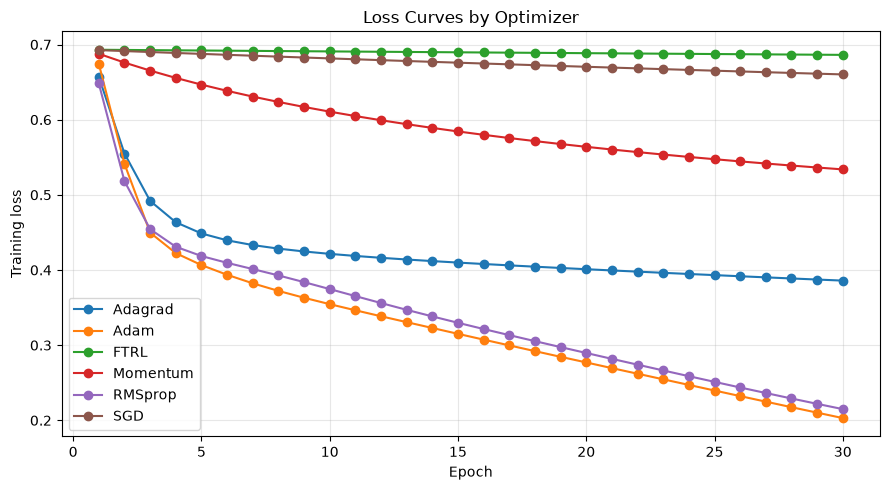

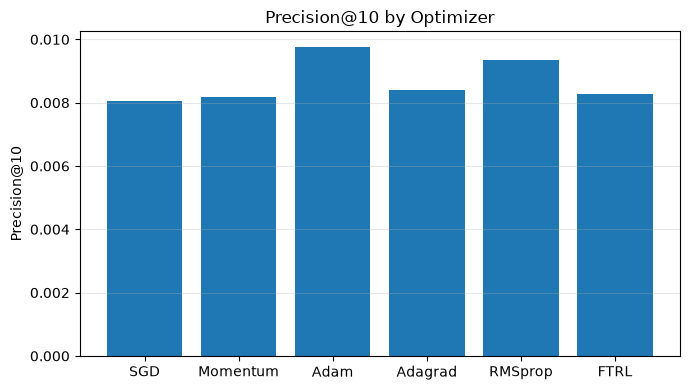

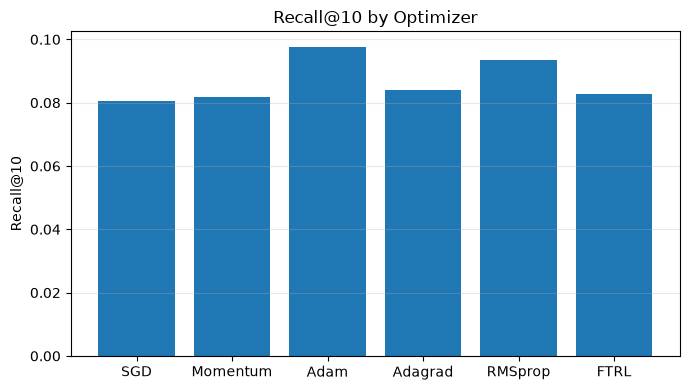

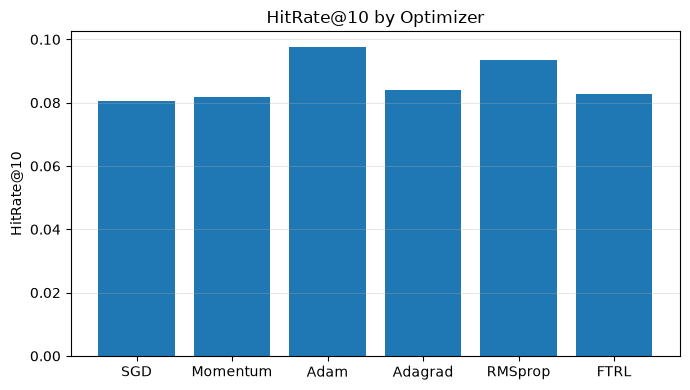

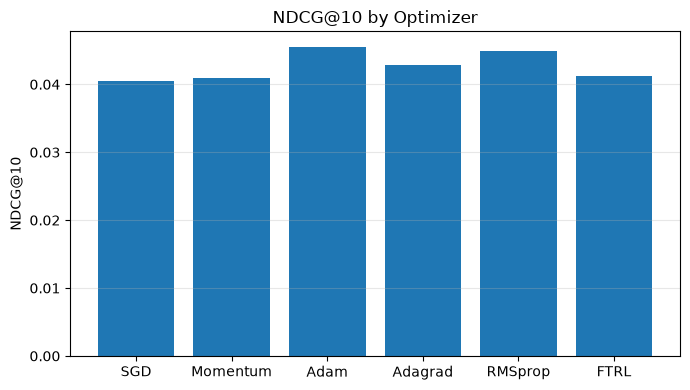

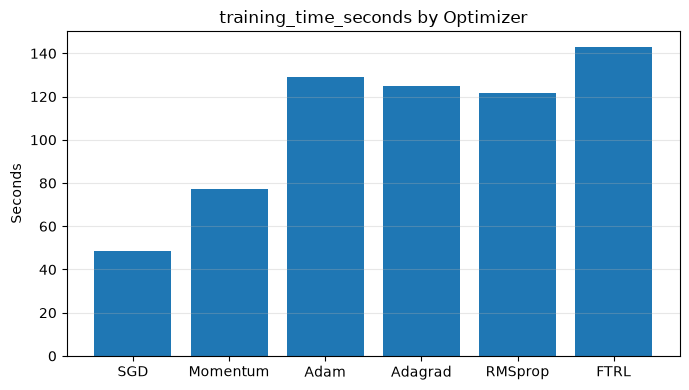

In [15]:
plt.figure(figsize=(9, 5))
for optimizer_name, group in optimizer_history_df.groupby("optimizer"):
    plt.plot(group["epoch"], group["loss"], marker="o", label=optimizer_name)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Loss Curves by Optimizer")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "optimizer_loss_curves.png", dpi=150)
plt.show()


def plot_metric_bar(metric_name, file_name, ylabel):
    plt.figure(figsize=(7, 4))
    plt.bar(optimizer_metrics_df["optimizer"], optimizer_metrics_df[metric_name])
    plt.ylabel(ylabel)
    plt.title(f"{metric_name} by Optimizer")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(figures_dir / file_name, dpi=150)
    plt.show()


plot_metric_bar("Precision@10", "optimizer_precision_at_10.png", "Precision@10")
plot_metric_bar("Recall@10", "optimizer_recall_at_10.png", "Recall@10")
plot_metric_bar("HitRate@10", "optimizer_hit_rate_at_10.png", "HitRate@10")
plot_metric_bar("NDCG@10", "optimizer_ndcg_at_10.png", "NDCG@10")
plot_metric_bar("training_time_seconds", "optimizer_training_time.png", "Seconds")


## Learning Rate Sensitivity

The main comparison uses one selected learning rate per optimizer for 30 epochs. This smaller experiment keeps the optimizer fixed, tries several learning rates, and trains for 10 epochs so we can compare sensitivity without mixing it into the main results.


Loading existing learning-rate sensitivity results: c:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\Optimisation\projet\workspace\results\tables\learning_rate_sensitivity.csv


,optimizer,learning_rate,final_loss,Precision@10,Recall@10,HitRate@10,NDCG@10,training_time_seconds
0,Adagrad,0.0050,0.472622,0.007749,0.077495,0.077495,0.039778,46.077055
1,Adagrad,0.0100,0.421479,0.007431,0.074310,0.074310,0.040077,43.631386
2,Adagrad,0.0500,0.221905,0.009342,0.093418,0.093418,0.046197,47.232902
3,Adam,0.0005,0.402995,0.008705,0.087049,0.087049,0.044703,55.656587
4,Adam,0.0010,0.354563,0.008917,0.089172,0.089172,0.045727,56.259706
5,Adam,0.0050,0.104652,0.008068,0.080679,0.080679,0.038491,57.221988
6,FTRL,0.0010,0.692912,0.008280,0.082803,0.082803,0.041178,15.572490
7,FTRL,0.0050,0.691976,0.008280,0.082803,0.082803,0.041178,15.622952
8,FTRL,0.0100,0.690816,0.008280,0.082803,0.082803,0.041178,15.752369
9,FTRL,0.0500,0.681904,0.008068,0.080679,0.080679,0.040565,15.659208


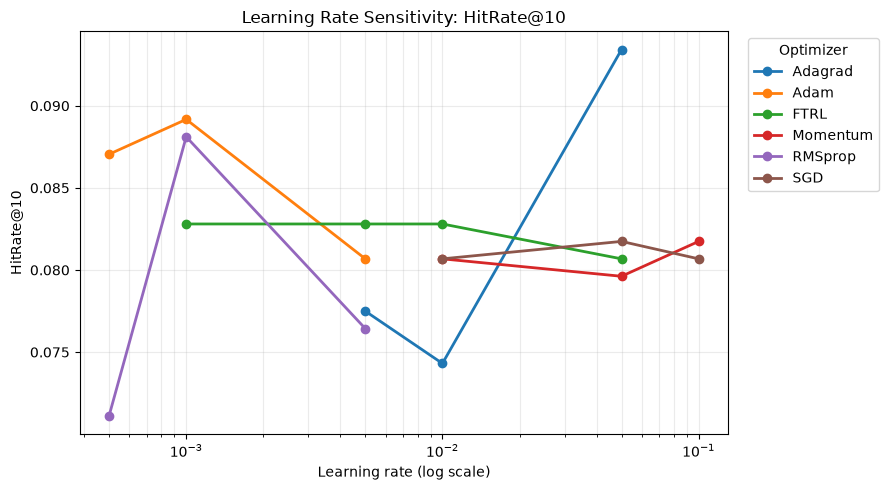

,optimizer,best_learning_rate,best_HitRate@10
0,Adagrad,0.050,0.093418
1,Adam,0.001,0.089172
2,FTRL,0.001,0.082803
3,Momentum,0.100,0.081741
4,RMSprop,0.001,0.088110
5,SGD,0.050,0.081741


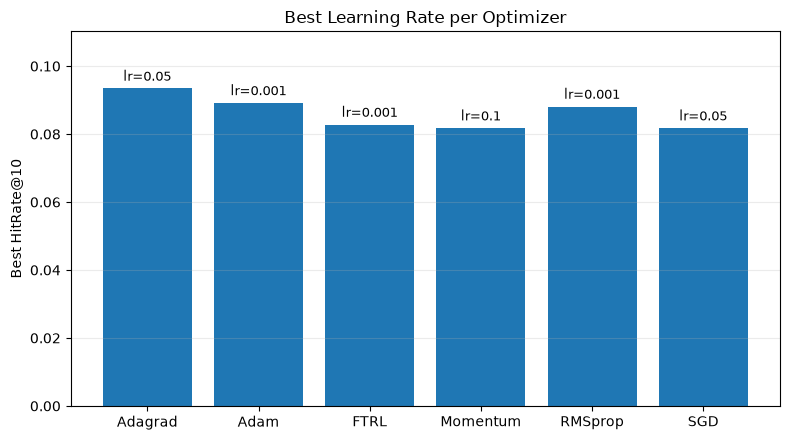

In [16]:
num_epochs_lr_sensitivity = 10
learning_rate_sensitivity_path = tables_dir / "learning_rate_sensitivity.csv"

learning_rate_grid = {
    "SGD": [0.01, 0.05, 0.1],
    "Momentum": [0.01, 0.05, 0.1],
    "Adam": [0.0005, 0.001, 0.005],
    "Adagrad": [0.005, 0.01, 0.05],
    "RMSprop": [0.0005, 0.001, 0.005],
}

if FTRL_AVAILABLE:
    learning_rate_grid["FTRL"] = [0.001, 0.005, 0.01, 0.05]
else:
    print("Skipping FTRL learning-rate sensitivity because pytorch-optimizer is not installed.")

if learning_rate_sensitivity_path.exists():
    print("Loading existing learning-rate sensitivity results:", learning_rate_sensitivity_path)
    learning_rate_sensitivity_df = pd.read_csv(learning_rate_sensitivity_path)
else:
    learning_rate_sensitivity_df = pd.DataFrame(columns=[
        "optimizer",
        "learning_rate",
        "final_loss",
        "Precision@10",
        "Recall@10",
        "HitRate@10",
        "NDCG@10",
        "training_time_seconds",
    ])

if not learning_rate_sensitivity_df.empty:
    learning_rate_sensitivity_df["learning_rate"] = pd.to_numeric(learning_rate_sensitivity_df["learning_rate"])
    learning_rate_sensitivity_df = learning_rate_sensitivity_df[
        learning_rate_sensitivity_df["optimizer"].isin(learning_rate_grid.keys())
    ].copy()

existing_runs = set()
if not learning_rate_sensitivity_df.empty:
    existing_runs = set(zip(
        learning_rate_sensitivity_df["optimizer"],
        learning_rate_sensitivity_df["learning_rate"].round(10),
    ))

lr_sensitivity_rows = []

for optimizer_name, learning_rates in learning_rate_grid.items():
    for lr in learning_rates:
        run_key = (optimizer_name, round(float(lr), 10))
        if run_key in existing_runs:
            continue

        print(f"Learning-rate sensitivity: {optimizer_name}, lr={lr}")

        model, history_df, training_time, _ = train_model(
            optimizer_name,
            lr,
            num_epochs_to_train=num_epochs_lr_sensitivity,
        )
        metrics = evaluate_model(model, test_data, k=K)
        synchronize_cuda()

        lr_sensitivity_rows.append({
            "optimizer": optimizer_name,
            "learning_rate": lr,
            "final_loss": history_df["loss"].iloc[-1],
            "Precision@10": metrics["Precision@10"],
            "Recall@10": metrics["Recall@10"],
            "HitRate@10": metrics["HitRate@10"],
            "NDCG@10": metrics["NDCG@10"],
            "training_time_seconds": training_time,
        })

        model.to("cpu")
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()

if lr_sensitivity_rows:
    learning_rate_sensitivity_df = pd.concat(
        [learning_rate_sensitivity_df, pd.DataFrame(lr_sensitivity_rows)],
        ignore_index=True,
    )

learning_rate_sensitivity_df["learning_rate"] = pd.to_numeric(learning_rate_sensitivity_df["learning_rate"])
learning_rate_sensitivity_df = learning_rate_sensitivity_df.sort_values(["optimizer", "learning_rate"]).reset_index(drop=True)
learning_rate_sensitivity_df.to_csv(learning_rate_sensitivity_path, index=False)

display(learning_rate_sensitivity_df)

plt.figure(figsize=(9, 5))
for optimizer_name, group in learning_rate_sensitivity_df.groupby("optimizer", sort=False):
    group = group.sort_values("learning_rate")
    plt.plot(
        group["learning_rate"],
        group["HitRate@10"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=optimizer_name,
    )

plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("HitRate@10")
plt.title("Learning Rate Sensitivity: HitRate@10")
plt.grid(True, which="both", axis="both", alpha=0.25)
plt.legend(title="Optimizer", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "learning_rate_sensitivity_hit_rate.png", dpi=150)
plt.show()

best_learning_rate_df = (
    learning_rate_sensitivity_df
    .sort_values(["optimizer", "HitRate@10", "NDCG@10"], ascending=[True, False, False])
    .groupby("optimizer", as_index=False)
    .first()[["optimizer", "learning_rate", "HitRate@10"]]
    .rename(columns={"learning_rate": "best_learning_rate", "HitRate@10": "best_HitRate@10"})
)

best_learning_rate_df.to_csv(tables_dir / "best_learning_rate_by_optimizer.csv", index=False)
display(best_learning_rate_df)

plt.figure(figsize=(8, 4.5))
bars = plt.bar(best_learning_rate_df["optimizer"], best_learning_rate_df["best_HitRate@10"])
bar_max = best_learning_rate_df["best_HitRate@10"].max()
plt.ylabel("Best HitRate@10")
plt.title("Best Learning Rate per Optimizer")
plt.ylim(0, bar_max * 1.18)
plt.grid(axis="y", alpha=0.25)

for bar, lr in zip(bars, best_learning_rate_df["best_learning_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar_max * 0.015,
        f"lr={lr:g}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(figures_dir / "best_learning_rate_by_optimizer.png", dpi=150)
plt.show()


## Final Comparison Table

This table combines convergence, recommendation quality, time, memory, and sparse-data behavior.

In [17]:
final_comparison_df = optimizer_metrics_df.merge(
    convergence_df[["optimizer", "stable_epoch"]],
    on="optimizer",
    how="left",
)

final_comparison_columns = [
    "optimizer",
    "learning_rate",
    "final_loss",
    "best_loss",
    "stable_epoch",
    "Precision@10",
    "Recall@10",
    "HitRate@10",
    "NDCG@10",
    "training_time_seconds",
    "memory_usage_mb",
    "inactive_users_count",
    "inactive_user_Precision@10",
    "inactive_user_Recall@10",
    "inactive_user_HitRate@10",
    "inactive_user_NDCG@10",
    "unpopular_items_count",
    "unpopular_item_Precision@10",
    "unpopular_item_Recall@10",
    "unpopular_item_HitRate@10",
    "unpopular_item_NDCG@10",
]

final_comparison_df = final_comparison_df[final_comparison_columns]

final_comparison_df = final_comparison_df.sort_values(
    by="HitRate@10",
    ascending=False
).reset_index(drop=True)

# Save full detailed table
final_comparison_df.to_csv(
    tables_dir / "final_optimizer_comparison_table.csv",
    index=False
)

display(final_comparison_df)

,optimizer,learning_rate,final_loss,best_loss,stable_epoch,Precision@10,Recall@10,HitRate@10,NDCG@10,training_time_seconds,...,inactive_users_count,inactive_user_Precision@10,inactive_user_Recall@10,inactive_user_HitRate@10,inactive_user_NDCG@10,unpopular_items_count,unpopular_item_Precision@10,unpopular_item_Recall@10,unpopular_item_HitRate@10,unpopular_item_NDCG@10
0,Adam,0.001,0.203005,0.203005,NaN,0.009766,0.097665,0.097665,0.045532,128.988508,...,239,0.012971,0.129707,0.129707,0.058065,25,0.0,0.0,0.0,0.0
1,RMSprop,0.001,0.214925,0.214925,NaN,0.009342,0.093418,0.093418,0.044952,121.724965,...,239,0.012971,0.129707,0.129707,0.058812,25,0.0,0.0,0.0,0.0
2,Adagrad,0.010,0.385888,0.385888,NaN,0.008386,0.083864,0.083864,0.042895,124.817251,...,239,0.010460,0.104603,0.104603,0.050847,25,0.0,0.0,0.0,0.0
3,FTRL,0.010,0.686210,0.686210,4.0,0.008280,0.082803,0.082803,0.041178,143.048179,...,239,0.010042,0.100418,0.100418,0.049591,25,0.0,0.0,0.0,0.0
4,Momentum,0.050,0.533848,0.533848,NaN,0.008174,0.081741,0.081741,0.040951,77.390044,...,239,0.009623,0.096234,0.096234,0.048692,25,0.0,0.0,0.0,0.0
5,SGD,0.050,0.660215,0.660215,30.0,0.008068,0.080679,0.080679,0.040565,48.787008,...,239,0.009623,0.096234,0.096234,0.048442,25,0.0,0.0,0.0,0.0


In [18]:
report_columns = [
    "optimizer",
    "learning_rate",
    "final_loss",
    "Precision@10",
    "Recall@10",
    "HitRate@10",
    "NDCG@10",
    "training_time_seconds",
    "memory_usage_mb",
    "inactive_user_HitRate@10",
    "unpopular_item_HitRate@10",
]

report_comparison_df = final_comparison_df[report_columns].copy()

# Round values for readability
report_comparison_df = report_comparison_df.round({
    "learning_rate": 4,
    "final_loss": 4,
    "Precision@10": 4,
    "Recall@10": 4,
    "HitRate@10": 4,
    "NDCG@10": 4,
    "training_time_seconds": 2,
    "memory_usage_mb": 2,
    "inactive_user_HitRate@10": 4,
    "unpopular_item_HitRate@10": 4,
})

# Save report-friendly table
report_comparison_df.to_csv(
    tables_dir / "report_optimizer_comparison_table.csv",
    index=False
)

display(report_comparison_df)

,optimizer,learning_rate,final_loss,Precision@10,Recall@10,HitRate@10,NDCG@10,training_time_seconds,memory_usage_mb,inactive_user_HitRate@10,unpopular_item_HitRate@10
0,Adam,0.001,0.2030,0.0098,0.0977,0.0977,0.0455,128.99,1.68,0.1297,0.0
1,RMSprop,0.001,0.2149,0.0093,0.0934,0.0934,0.0450,121.72,1.35,0.1297,0.0
2,Adagrad,0.010,0.3859,0.0084,0.0839,0.0839,0.0429,124.82,1.68,0.1046,0.0
3,FTRL,0.010,0.6862,0.0083,0.0828,0.0828,0.0412,143.05,2.38,0.1004,0.0
4,Momentum,0.050,0.5338,0.0082,0.0817,0.0817,0.0410,77.39,1.31,0.0962,0.0
5,SGD,0.050,0.6602,0.0081,0.0807,0.0807,0.0406,48.79,1.31,0.0962,0.0


In [19]:
def select_optimizer(df, column, higher_is_better=True, zero_means_no_winner=False):
    clean_df = df.dropna(subset=[column]).copy()

    if clean_df.empty:
        return {
            "criterion": column,
            "optimizer": "No result",
            "value": None,
        }

    if zero_means_no_winner and clean_df[column].max() == 0:
        return {
            "criterion": column,
            "optimizer": "No optimizer achieved a positive score",
            "value": 0,
        }

    index = clean_df[column].idxmax() if higher_is_better else clean_df[column].idxmin()
    row = clean_df.loc[index]

    return {
        "criterion": column,
        "optimizer": row["optimizer"],
        "value": row[column],
    }


recommendation_rows = [
    {"decision": "Best optimizer by HitRate@10", **select_optimizer(final_comparison_df, "HitRate@10")},
    {"decision": "Best optimizer by NDCG@10", **select_optimizer(final_comparison_df, "NDCG@10")},
    {"decision": "Fastest optimizer by training time", **select_optimizer(final_comparison_df, "training_time_seconds", higher_is_better=False)},
    {"decision": "Optimizer with lowest final loss", **select_optimizer(final_comparison_df, "final_loss", higher_is_better=False)},
    {"decision": "Best optimizer for inactive users", **select_optimizer(final_comparison_df, "inactive_user_HitRate@10")},
    {
        "decision": "Best optimizer for unpopular items",
        **select_optimizer(
            final_comparison_df,
            "unpopular_item_HitRate@10",
            zero_means_no_winner=True
        )
    },
]

final_recommendation_df = pd.DataFrame(recommendation_rows)
final_recommendation_df.to_csv(tables_dir / "final_optimizer_recommendations.csv", index=False)

display(final_recommendation_df)


,decision,criterion,optimizer,value
0,Best optimizer by HitRate@10,HitRate@10,Adam,0.097665
1,Best optimizer by NDCG@10,NDCG@10,Adam,0.045532
2,Fastest optimizer by training time,training_time_seconds,SGD,48.787008
3,Optimizer with lowest final loss,final_loss,Adam,0.203005
4,Best optimizer for inactive users,inactive_user_HitRate@10,Adam,0.129707
5,Best optimizer for unpopular items,unpopular_item_HitRate@10,No optimizer achieved a positive score,0.000000


## Final Recommendation

The table above automatically identifies the strongest optimizer under each criterion: overall `HitRate@10`, overall `NDCG@10`, training time, final loss, inactive-user `HitRate@10`, and unpopular-item `HitRate@10`. If FTRL is available, it is included in these decisions exactly like the other optimizers.

The final optimizer choice should balance recommendation quality, convergence speed, stability, training time, and sparse-data behavior. In a recommender system, the optimizer with the lowest training loss is not always the best final choice if it trains slowly, produces unstable curves, or performs poorly for inactive users and unpopular items.

Because FTRL comes from an external package, its implementation source is different from `torch.optim` optimizers, but it is still compared using the same model, data, and metrics.


## Conclusion

This notebook compares SGD, SGD with Momentum, Adam, Adagrad, RMSprop, and FTRL when `pytorch-optimizer` is installed. All optimizers use the same implicit Matrix Factorization model, train/test split, negative sampling, hyperparameter structure, and evaluation metrics. The saved tables and figures can be used directly in the final report.
